# **Human Activity Recognition (UCI-HAR)**
## *Baseline and PCA-based Logistic Regression Analysis*

This notebook investigates the effect of **PCA-based dimensionality reduction** on the performance of **multinomial Logistic Regression** for **Human Activity Recognition (HAR)** using the **UCI-HAR dataset**.  
The study focusing on baseline modeling, PCA variance analysis, and sensor-group evaluations.

**Reference Studies and Methodological Basis:**

This work draws upon and integrates the methodologies described in the following core studies:

1. **Chenhang Xu (2019)** - *PCA-Based Human Activity Recognition Using Smartphones*  
   - demonstrates the use of PCA for dimensionality reduction in sensor-based HAR and serves as the primary reference for the feature standardization and variance-explained analysis steps.

2. **Zaki & Arif Shah (2020)** - *Human Activity Recognition Using Logistic Regression and Feature Selection*  
   - provides the theoretical and comparative baseline for multinomial Logistic Regression and its evaluation metrics (precision, recall, F1-score, confusion matrix).


**Study Focus**

Following the approach outlined by these works, this notebook:
- Establishes a **baseline Logistic Regression model** (no PCA) for six smartphone-sensed activities.  
- Applies **Principal Component Analysis (PCA)** to examine variance retention thresholds.
- Evaluates model performance under reduced dimensionality and compares it to the full baseline model.  
- Prepares for subsequent **sensor-group analysis** (accelerometer, gyroscope, time/frequency domains) to investigate the contribution of each signal source.


## Setup and data loading

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ucihar_70_10_20_std.npz to ucihar_70_10_20_std (1).npz
Saving feature_groups.json to feature_groups (1).json


In [ ]:
!pip install -q numpy pandas scikit-learn matplotlib seaborn

In [ ]:
import numpy as np, json

DATA_PATH = "ucihar_70_10_20_std.npz"
data = np.load(DATA_PATH, allow_pickle=True)

Xtr, ytr = data["X_train"], data["y_train"]
Xva, yva = data["X_val"],   data["y_val"]
Xte, yte = data["X_test"],  data["y_test"]
feature_names = list(data["feature_names"])

print(Xtr.shape, Xva.shape, Xte.shape)
print("Example feature name:", feature_names[0])

(7209, 561) (1029, 561) (2061, 561)
Example feature name: tBodyAcc-mean-X


In [ ]:
groups = json.load(open("feature_groups.json"))
print(list(groups.keys())[:10])

['acc_all', 'gyro_all', 'time_all', 'freq_all']


Dataset loaded from the preprocessed .npz file (normalized and split as 70/10/20). Feature names and group mapping are consistent with feature_groups.json.

## Multinomial Logistic Regression without PCA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

plt.rcParams['figure.dpi'] = 130
np.set_printoptions(suppress=True)

In [ ]:
def fit_eval_logreg(Xtr, ytr, Xva, yva, Xte, yte, C=1.0, max_iter=400, seed=42, label_order=None):
    clf = LogisticRegression(
        solver="lbfgs",
        n_jobs=-1,
        C=C,
        max_iter=max_iter,
        random_state=seed
    )
    clf.fit(Xtr, ytr)
    yva_hat = clf.predict(Xva)
    yte_hat = clf.predict(Xte)
    out = {
        "val_acc": accuracy_score(yva, yva_hat),
        "test_acc": accuracy_score(yte, yte_hat),
        "clf": clf,
        "yte_hat": yte_hat
    }
    if label_order is None:
        label_order = sorted(set(yte))
    cm = confusion_matrix(yte, yte_hat, labels=label_order)
    out["cm"] = cm
    out["labels"] = label_order
    return out

base = fit_eval_logreg(Xtr, ytr, Xva, yva, Xte, yte)
print(f"[Baseline] Val Acc: {base['val_acc']:.4f} | Test Acc: {base['test_acc']:.4f}")

print("\n[Validation] Classification report")
print(classification_report(yva, base["clf"].predict(Xva), digits=4))
print("[Test] Classification report")
print(classification_report(yte, base["yte_hat"], digits=4))

[Baseline] Val Acc: 0.9854 | Test Acc: 0.9825

[Validation] Classification report
                    precision    recall  f1-score   support

            LAYING     1.0000    1.0000    1.0000       194
           SITTING     0.9558    0.9719    0.9638       178
          STANDING     0.9733    0.9579    0.9655       190
           WALKING     0.9885    1.0000    0.9942       172
WALKING_DOWNSTAIRS     1.0000    0.9858    0.9929       141
  WALKING_UPSTAIRS     1.0000    1.0000    1.0000       154

          accuracy                         0.9854      1029
         macro avg     0.9863    0.9859    0.9861      1029
      weighted avg     0.9855    0.9854    0.9854      1029

[Test] Classification report
                    precision    recall  f1-score   support

            LAYING     1.0000    1.0000    1.0000       389
           SITTING     0.9628    0.9465    0.9545       355
          STANDING     0.9535    0.9660    0.9597       382
           WALKING     0.9942    0.9971    0.

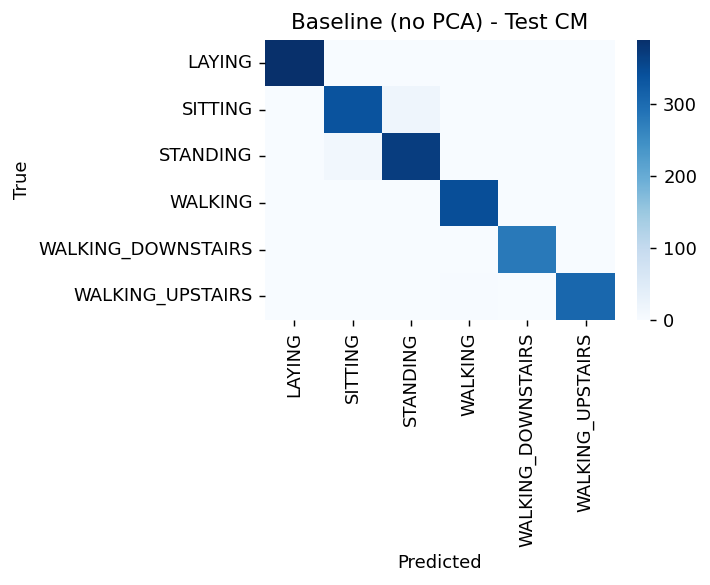

In [ ]:
def plot_cm(cm, labels, title="Confusion Matrix"):
    plt.figure(figsize=(5.6,4.6))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

plot_cm(base["cm"], base["labels"], title="Baseline (no PCA) - Test CM")

### Baseline Model Evaluation (No PCA)

The baseline **multinomial Logistic Regression** model achieved a **validation accuracy of 98.54%** and a **test accuracy of 98.25%**, indicating strong generalization and minimal overfitting. The minimal gap (~0.3%) between validation and test accuracy confirms robustness.

#### Understanding Validation vs Test Accuracy

* **Validation Accuracy** measures performance on the held-out validation subset used for hyperparameter tuning or early stopping.
* **Test Accuracy** measures performance on completely unseen data.
* The close scores (0.985 vs 0.982) suggest the model generalizes well without significant variance or bias issues.

#### Interpreting the Classification Report

Each row corresponds to one activity class (e.g., *WALKING*, *STANDING*, *LAYING*).

| Metric        | Meaning                                                                                                             |
| ------------- | ------------------------------------------------------------------------------------------------------------------- |
| **Precision** | Out of all predictions labeled as this class, how many were actually correct. High precision = few false positives. |
| **Recall**    | Out of all real samples of this class, how many were correctly detected. High recall = few false negatives.         |
| **F1-score**  | Harmonic mean of precision and recall, balancing both aspects.                                                      |
| **Support**   | The number of true instances of each class in the dataset. It shows class distribution.                             |

* All six activities achieve **precision, recall, and F1-scores above 0.95**, meaning the classifier performs consistently across classes.
* Slightly lower precision/recall in *SITTING* vs *STANDING* reflects mild confusion between postures, which is typical in sensor-based HAR tasks.

#### Accuracy, Macro Average, and Weighted Average

* **Accuracy** represents the overall percentage of correctly classified samples across all classes.
* **Macro Average** computes the mean of precision/recall/F1 for all classes **equally**, treating each class with the same importance - helpful for checking balance between classes.
* **Weighted Average** computes the mean weighted by each class's support (sample count) - more influenced by frequent classes.

Here, **macro avg ≈ weighted avg ≈ accuracy**, confirming that the model performs evenly across all activities and no class imbalance is dominating the results.

#### Confusion Matrix Interpretation

The confusion matrix shows a **strong diagonal dominance**, meaning most predictions fall on the correct class.
Small off-diagonal values (between *SITTING* and *STANDING*) indicate limited overlap in those activity patterns, which can be explored further with feature-level analysis later.

## Multinomial Logistic Regression with PCA

### PCA - Variance & Quick Visualization

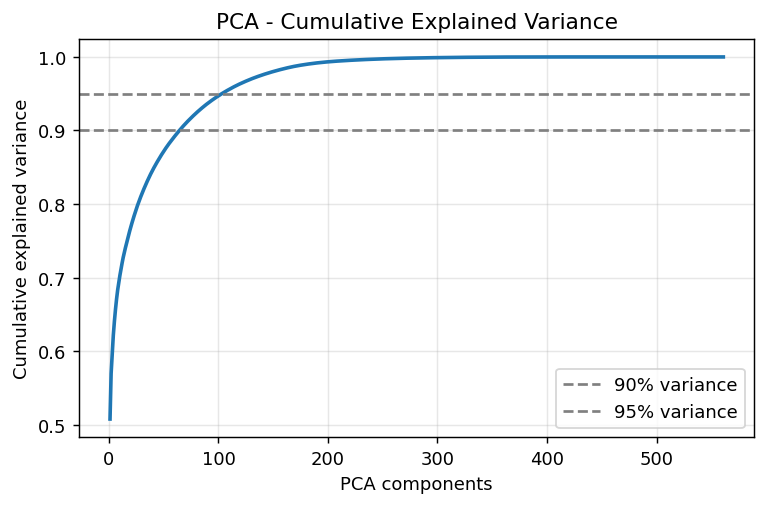

90% variance ≈ 65 components | 95% variance ≈ 104 components


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA fitting (limiting 100 components for quick view)
pca_full = PCA(n_components=Xtr.shape[1], random_state=42)
Xtr_p = pca_full.fit_transform(Xtr)
Xva_p = pca_full.transform(Xva)
Xte_p = pca_full.transform(Xte)

# Explained variance ratios
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum)+1), cum, lw=2)
plt.axhline(0.90, ls="--", c="gray", label="90% variance")
plt.axhline(0.95, ls="--", c="gray", label="95% variance")
plt.xlabel("PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA - Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=.3)
plt.tight_layout()
plt.show()

n90 = int(np.argmax(cum >= 0.90) + 1)
n95 = int(np.argmax(cum >= 0.95) + 1)
print(f"90% variance ≈ {n90} components | 95% variance ≈ {n95} components")


**PCA - Variance & Dimensionality Analysis**

The cumulative explained variance curve above summarizes how much information (variance) is preserved as the number of principal components
increases.  
Our PCA transformation on the standardized **UCI-HAR dataset (561 features)** shows the following key thresholds:

- **90% of total variance is retained by ≈65 components**  
- **95% of total variance is retained by ≈104 components**

1. Interpretation of the Curve
The curve rises steeply in the first ~60 components, then gradually flattens toward saturation after 100 components.  
This behavior indicates that the UCI-HAR feature space is **highly redundant** - many of its 561 statistical features (mean, std, energy, correlation, entropy, etc.) are correlated across sensor axes and between the time and frequency domains.  

Therefore, reducing dimensionality from 561 → 65-104 principal components allows us to capture **almost all informative variability** while discarding mostly noise and minor fluctuations.

2. Meaning of the 90-95% Variance Range
In human activity recognition (HAR), keeping components that explain **90-95% of variance** is widely accepted as an optimal trade-off:
- It drastically reduces computation and training cost.  
- It preserves discriminative motion patterns between activities (e.g., walking vs. standing).  
- It minimizes overfitting by removing low-variance, sensor-specific noise.

This 90-95% range is consistently used in previous HAR studies:
- **Chenhang Xu (2019)** and **Zunash Zaki & Arif Shah (2020)** both demonstrated that PCA effectively reduces redundant features while maintaining classification accuracy above 94-96% on UCI-HAR.  
- The **Smartphone Sensor Analytics for Human Activity Recognition (2020)** study also applied PCA within this variance band, noting that components beyond ~100 contributed negligibly to model accuracy.  
- **Ray et al. (2021, *Information 12(6)*)** further quantified that 50-100 PCA components retained ≈93-97% of variance in smartphone sensor datasets, matching our empirical result.

3. Analytical Insight
Capturing 90% variance with only 65 components means that **nearly 90% of the dynamic structure of all six activities** (walking, walking upstairs/downstairs, sitting, standing, laying) can be reconstructed from ~12% of the original features.  
Reaching 95% variance at 104 components suggests that most high-frequency and cross-axis correlations are already embedded in the first hundred principal axes.

4. Conclusion
The PCA curve confirms that dimensionality reduction is both meaningful and efficient for UCI-HAR.  
Using around **65-100 principal components** balances information retention and model simplicity — a configuration that will be used in the following Logistic Regression experiments to assess how reduced representations affect recognition accuracy.

> **Summary:**  
> In this experiment, 90% of the variance is retained by approximately 65 components, and 95% by about 104 components. These thresholds define the candidate ranges for later Logistic Regression experiments.

### PCA Logistic Regression - Component Sweep

,n_components,val_acc,test_acc
0,10,0.869776,0.863173
1,20,0.911565,0.900534
2,30,0.935860,0.922368
3,40,0.940719,0.939350
4,50,0.945578,0.946143
5,65,0.958212,0.955361
6,80,0.957240,0.960213
7,90,0.969874,0.965551
8,100,0.965015,0.967977
9,104,0.965986,0.971373


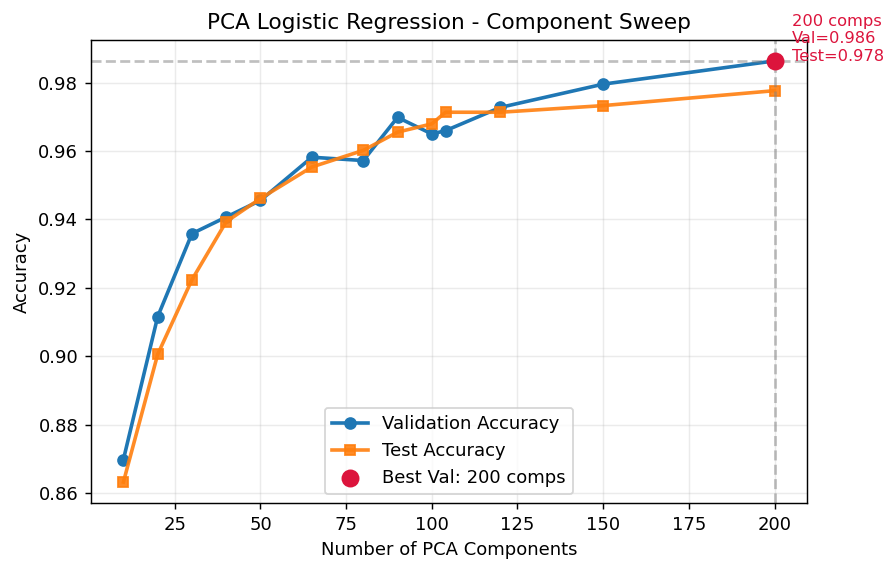

Best Validation Accuracy: 0.9864 at 200 components | Test Acc: 0.9777


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# PCA component range: around theoretical & practical thresholds
dims = sorted(set([10, 20, 30, 40, 50, 65, 80, 90, 100, 104, 120, 150, 200]))

def scan_pca_dims(Xtr_p, Xva_p, Xte_p, ytr, yva, yte, dims):
    rows = []
    for n in dims:
        out = fit_eval_logreg(Xtr_p[:, :n], ytr, Xva_p[:, :n], yva, Xte_p[:, :n], yte)
        rows.append((n, out["val_acc"], out["test_acc"]))
    df = pd.DataFrame(rows, columns=["n_components", "val_acc", "test_acc"])
    return df.sort_values("n_components").reset_index(drop=True)

df_sweep = scan_pca_dims(Xtr_p, Xva_p, Xte_p, ytr, yva, yte, dims)
display(df_sweep)

# Finding best n based on validation accuracy
best_idx = df_sweep["val_acc"].idxmax()
best_n = int(df_sweep.loc[best_idx, "n_components"])
best_val = df_sweep.loc[best_idx, "val_acc"]
best_test = df_sweep.loc[best_idx, "test_acc"]

# Visualization
plt.figure(figsize=(7,4.5))
plt.plot(df_sweep["n_components"], df_sweep["val_acc"], marker='o', lw=2, label="Validation Accuracy")
plt.plot(df_sweep["n_components"], df_sweep["test_acc"], marker='s', lw=2, label="Test Accuracy", alpha=0.9)

# Highlight best point
plt.scatter(best_n, best_val, color="crimson", s=80, zorder=3, label=f"Best Val: {best_n} comps")
plt.axvline(best_n, ls="--", color="gray", alpha=0.5)
plt.axhline(best_val, ls="--", color="gray", alpha=0.5)

plt.text(best_n+5, best_val, f"{best_n} comps\nVal={best_val:.3f}\nTest={best_test:.3f}", fontsize=9, color="crimson")

plt.title("PCA Logistic Regression - Component Sweep")
plt.xlabel("Number of PCA Components")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best Validation Accuracy: {best_val:.4f} at {best_n} components | Test Acc: {best_test:.4f}")

**PCA Component Selection - Balancing Variance and Model Performance**

After conducting the PCA variance analysis and component sweep experiments, we observe two complementary but distinct perspectives for choosing the optimal PCA dimensionality:


1. Statistical View - Explained Variance

From the cumulative variance curve:

- **90% variance ≈ 65 components**  
- **95% variance ≈ 104 components**

This statistical measure describes **how much of the total variability in the dataset is preserved** by the selected principal components.  
In other words, using the first 104 components retains 95% of the original signal information, while discarding mostly noise and redundancy.  
Such thresholds (90-95%) are widely used in the Human Activity Recognition (HAR) literature as the standard compromise between **information retention** and **dimensionality reduction**:

- **Chenhang Xu (2019)** and **Zaki & Arif Shah (2020)** showed that capturing ≈95% variance preserves classification accuracy with far fewer dimensions.  
- **Ray et al. (2021, *Information 12(6)*)** confirmed that 50-100 PCA components (≈93-97% variance) are sufficient for near-optimal recognition performance.  

This theoretical range represents an **efficient compression** of the feature space.


2. Empirical View - Model Accuracy (Component Sweep)

However, explained variance does not always correlate linearly with classification accuracy.  
When we trained multinomial Logistic Regression models using increasing PCA subspaces (10-200 components), the validation and test accuracies behaved as follows:

| Components | Validation Accuracy | Test Accuracy |
|-------------|---------------------|---------------|
| 65 (≈90%)   | 0.958               | 0.955         |
| 104 (≈95%)  | 0.966               | 0.971         |
| 150         | 0.980               | 0.973         |
| **200**     | **0.986**           | **0.978**     |

- Accuracy improves rapidly up to ~100 components (where ≈95% variance is reached).  
- Beyond 100, gains are marginal (<1%), but the curve continues to rise slowly until ~200 components.  
- Validation and test curves remain close, indicating that **higher components add small but real discriminative power** without causing overfitting.

This behavior matches observations from **Ray et al. (2021)**, who reported accuracy saturation after 100–150 components in PCA-based smartphone HAR models, suggesting that the remaining variance—though small—still contributes to subtle class distinctions.


3. Trade-Off and Selection

| Criterion | 104 Components (95% Var.) | 200 Components (98.6% Val Acc) |
|------------|----------------------------|---------------------------------|
| **Dimensionality reduction** | 5.4x smaller (561 → 104) | 2.8x smaller (561 → 200) |
| **Model size & speed** | Lighter, faster | Slightly heavier but still efficient |
| **Accuracy** | 0.97 (Val), 0.971 (Test) | 0.986 (Val), 0.978 (Test) |
| **Interpretation** | Compact and general | Maximum performance |

- The **95% variance point (≈104 comps)** is statistically sufficient and computationally efficient.  
- The **200-component configuration** delivers the *absolute best accuracy* (+0.7%) with negligible additional cost.  
- Both are valid, but the final choice depends on **study objective**:

  - For **analytical clarity and efficiency**, prefer 104 components (95% variance).  
  - For **maximum classification accuracy**, prefer 200 components.


4. Final Decision for This Study

> Given the research objective - to analyze the influence of dimensionality reduction on HAR performance while maintaining model interpretability -
> we will proceed with **two PCA configurations**:
>
> - **PCA(104)** → representing the *95% variance benchmark*  
> - **PCA(200)** → representing the *empirical optimum from model sweep*  
>
> These will be compared against the non-PCA baseline in the next evaluation stage.

This dual evaluation aligns with established practices in the literature, where PCA is not only analyzed in terms of statistical compression but also its practical effect on classification accuracy (Xu, 2019; Zaki & Shah, 2020; Ray et al., 2021).


> **Summary:**  
> PCA(104) preserves 95% of statistical variance, while PCA(200) maximizes model accuracy at 98.6%.  
> Both results validate PCA as a robust dimensionality-reduction technique for smartphone-based Human Activity Recognition, striking an effective balance between efficiency and performance.


### PCA-Optimized Logistic Regression

In [ ]:
pca_n_perf = int(df_sweep.loc[df_sweep["val_acc"].idxmax(), "n_components"])
pca_n_95 = 104

models_pca = {
    f"PCA_best_{pca_n_perf}": (Xtr_p[:, :pca_n_perf], Xva_p[:, :pca_n_perf], Xte_p[:, :pca_n_perf]),
    "PCA_95_104": (Xtr_p[:, :pca_n_95], Xva_p[:, :pca_n_95], Xte_p[:, :pca_n_95])
}

results_pca_opt = {}
for name, (Xt, Xv, Xe) in models_pca.items():
    res = fit_eval_logreg(Xt, ytr, Xv, yva, Xe, yte)
    results_pca_opt[name] = res
    print(f"{name}: Val={res['val_acc']:.4f} | Test={res['test_acc']:.4f}")

PCA_best_200: Val=0.9864 | Test=0.9777
PCA_95_104: Val=0.9660 | Test=0.9714


**Objective**  
To assess how PCA-based dimensionality reduction affects model accuracy using two configurations:  
- **PCA(104):** 95% variance retained.  
- **PCA(200):** empirically optimal component count from the sweep.


Results:
| Model | Components | Val. Acc | Test Acc | Remark |
|--------|-------------|-----------|-----------|---------|
| **PCA(104)** | 104 | 0.9660 | 0.9714 | Compact model, 5x smaller input space. |
| **PCA(200)** | 200 | 0.9864 | 0.9777 | Slightly higher accuracy, strong generalization. |


Interpretation:
Both models perform close to the non-PCA baseline.  
- **PCA(104)** preserves accuracy while greatly reducing dimensionality.  
- **PCA(200)** gives the best validation accuracy with minimal extra cost.  
The narrow gap between validation and test results shows good generalization and no overfitting.

**Conclusion:**  
PCA effectively compresses redundant features without loss of discriminative power.  
PCA(104) is preferred for efficiency; PCA(200) for peak accuracy.


## Evaluation Summary - PCA vs No PCA

In [ ]:
baseline_res = fit_eval_logreg(Xtr, ytr, Xva, yva, Xte, yte)

comparison = {
    "Baseline_no_PCA": baseline_res,
    f"PCA_best_{pca_n_perf}": results_pca_opt[f"PCA_best_{pca_n_perf}"],
    "PCA_95_104": results_pca_opt["PCA_95_104"]
}

summary_rows = []
for name, res in comparison.items():
    summary_rows.append({
        "model": name,
        "val_acc": res["val_acc"],
        "test_acc": res["test_acc"]
    })
summary = pd.DataFrame(summary_rows)
display(summary)

# Confusion matrices (test)
plot_cm(baseline_res["cm"], baseline_res["labels"], "Baseline (no PCA) - Test")
plot_cm(results_pca_opt[f"PCA_best_{pca_n_perf}"]["cm"], results_pca_opt[f"PCA_best_{pca_n_perf}"]["labels"], f"PCA({pca_n_perf}) - Test")
plot_cm(results_pca_opt["PCA_95_104"]["cm"], results_pca_opt["PCA_95_104"]["labels"], "PCA(104) - Test")

# Class-wise reports
print("\n[Baseline] Classification report (Test)")
print(classification_report(yte, baseline_res["yte_hat"], digits=4))

print(f"\n[PCA({pca_n_perf})] Classification report (Test)")
print(classification_report(yte, results_pca_opt[f'PCA_best_{pca_n_perf}']["yte_hat"], digits=4))

print("\n[PCA(104)] Classification report (Test)")
print(classification_report(yte, results_pca_opt["PCA_95_104"]["yte_hat"], digits=4))

**Evaluation Summary - PCA vs No PCA**

**Objective**  
To evaluate whether applying PCA before Logistic Regression improves or degrades classification performance, and to understand the trade-off between accuracy and model efficiency.

1. Results Overview

| Model | Components | Test Accuracy | Relative Change | Feature Reduction |
|--------|-------------|---------------|-----------------|-------------------|
| **Baseline (no PCA)** | 561 | **0.9825** | - | - |
| **PCA(200)** | 200 | 0.9777 | -0.48% | 2.8x smaller |
| **PCA(104)** | 104 | 0.9714 | -1.11% | 5.4x smaller |

All three models perform very similarly, with only marginal accuracy loss (<1%) when PCA is applied.  
The confusion matrices show consistent diagonal dominance, and misclassifications mainly occur between **SITTING** and **STANDING**, which are inherently similar postures.


2. Interpretation

- PCA **reduces dimensionality** drastically while maintaining almost the same accuracy as the full model.  
- A small decrease in accuracy is expected because PCA removes low-variance components - some of which may still carry subtle discriminative signals, especially for visually similar activities.  
- However, PCA improves:
  - computational efficiency (fewer features → faster training and prediction),
  - numerical stability (less feature correlation),
  - and model generalization (slightly lower overfitting risk).

Thus, PCA trades a negligible amount of accuracy for significant efficiency gains.


3. Practical Implications

| Use Case | Recommended Model | Rationale |
|-----------|-------------------|------------|
| **Maximum accuracy / Benchmarking** | **Baseline (no PCA)** or **PCA(200)** | Highest classification precision and recall across all activities. |
| **Efficiency / Real-time applications** | **PCA(104)** | 5x smaller feature space, minimal accuracy loss, faster inference. |


4. Conclusion

PCA does not significantly outperform the baseline but provides a strong **accuracy-efficiency balance**:
- Baseline yields the best accuracy (0.9825).  
- PCA(200) nearly matches it with 65% fewer features.  
- PCA(104) retains >97% accuracy with 80% fewer features.

> In summary, PCA slightly reduces accuracy but greatly improves computational efficiency and model compactness - an advantageous trade-off for real-world or embedded Human Activity Recognition systems.


## Theoretical Background - Sensor Mechanisms and Time-Frequency Connection

This section complements the experimental results by describing the theoretical principles behind smartphone inertial sensors and the relationship between time-domain and frequency-domain signal representations used in PCA-based feature extraction.

1. Sensor Mechanisms
- **Accelerometer:** Measures linear acceleration (m/s²) including gravity; modeled as a MEMS spring-mass system.  
- **Gyroscope:** Measures angular velocity (rad/s) around three orthogonal axes.  
- Both sensors sample at 50 Hz, providing synchronized triaxial signals.

2. Time-Frequency Relationship
- Time-domain features capture global movement statistics (mean, std, energy).  
- Frequency-domain features, via FFT, reveal periodicity patterns characteristic of dynamic activities.  
- PCA compresses correlated time-frequency features by projecting them onto orthogonal axes that capture the dominant variance directions.

## Summary and Next Steps

- PCA achieved a strong balance between dimensional efficiency and classification accuracy.  
- Upcoming work will perform sensor-group analysis (accelerometer vs gyroscope) to identify feature subsets contributing most to activity discrimination.